In [13]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [14]:
df = pd.read_csv("dataset_balanced_final.csv")

df["Label"] = df["Label"].map({
    "NORMAL":0,
    "ATTACK":1
})

In [15]:
X = df.drop("Label",axis=1)

y = df["Label"]

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.30,

    stratify=y,

    random_state=42

)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    stratify=y_temp,

    random_state=42

)

In [17]:
print("="*60)

print("TRAIN")

print(X_train.shape)

print(y_train.value_counts())

print()

print("="*60)

print("VALIDATION")

print(X_val.shape)

print(y_val.value_counts())

print()

print("="*60)

print("TEST")

print(X_test.shape)

print(y_test.value_counts())

TRAIN
(7427, 7)
Label
1    3714
0    3713
Name: count, dtype: int64

VALIDATION
(1591, 7)
Label
0    796
1    795
Name: count, dtype: int64

TEST
(1592, 7)
Label
1    796
0    796
Name: count, dtype: int64


In [18]:
rf = RandomForestClassifier(

    bootstrap=False,

    max_depth=15,

    max_features="sqrt",

    min_samples_leaf=2,

    min_samples_split=5,

    n_estimators=50,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train,

    y_train

)

RandomForestClassifier(bootstrap=False, max_depth=15, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [19]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Flow Bytes/s,0.388708
6,Init_Win_bytes_forward,0.236116
2,Flow Packets/s,0.125701
0,Flow Duration,0.116697
4,SYN Flag Count,0.063618
5,ACK Flag Count,0.035983
3,Total Fwd Packets,0.033176


In [20]:
print("="*60)

print("FEATURE IMPORTANCE")

print("="*60)

print(importance)

FEATURE IMPORTANCE
                  Feature  Importance
1            Flow Bytes/s    0.388708
6  Init_Win_bytes_forward    0.236116
2          Flow Packets/s    0.125701
0           Flow Duration    0.116697
4          SYN Flag Count    0.063618
5          ACK Flag Count    0.035983
3       Total Fwd Packets    0.033176


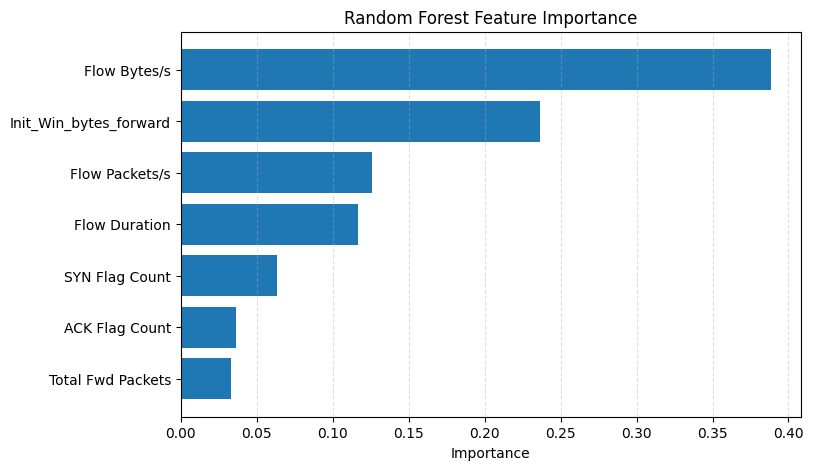

In [21]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

In [22]:
importance["Percentage"] = importance["Importance"] * 100

importance

,Feature,Importance,Percentage
1,Flow Bytes/s,0.388708,38.870776
6,Init_Win_bytes_forward,0.236116,23.611638
2,Flow Packets/s,0.125701,12.570086
0,Flow Duration,0.116697,11.669748
4,SYN Flag Count,0.063618,6.361832
5,ACK Flag Count,0.035983,3.598344
3,Total Fwd Packets,0.033176,3.317576


In [23]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature Importance berhasil disimpan")

Feature Importance berhasil disimpan


In [24]:
joblib.dump(

    rf,

    "rf_orangepi.joblib"

)

print("Model berhasil disimpan")

Model berhasil disimpan


In [26]:
import os

size = os.path.getsize("rf_orangepi.joblib")

print("Ukuran Model : %.2f KB"%(size/1024))

Ukuran Model : 1814.70 KB


In [27]:
y_val_pred = rf.predict(X_val)

y_val_prob = rf.predict_proba(X_val)[:,1]

print("="*60)

print("VALIDATION RESULT")

print("="*60)

print()

print("Accuracy :",accuracy_score(y_val,y_val_pred))

print("Precision :",precision_score(y_val,y_val_pred))

print("Recall :",recall_score(y_val,y_val_pred))

print("F1 :",f1_score(y_val,y_val_pred))

print("ROC :",roc_auc_score(y_val,y_val_prob))

print()

print(classification_report(

    y_val,

    y_val_pred,

    target_names=[

        "NORMAL",

        "ATTACK"

    ]

))

VALIDATION RESULT

Accuracy : 0.9811439346323068
Precision : 0.9835651074589128
Recall : 0.9786163522012579
F1 : 0.9810844892812106
ROC : 0.996627793053317

              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       796
      ATTACK       0.98      0.98      0.98       795

    accuracy                           0.98      1591
   macro avg       0.98      0.98      0.98      1591
weighted avg       0.98      0.98      0.98      1591



In [28]:
y_test_pred = rf.predict(X_test)

y_test_prob = rf.predict_proba(X_test)[:,1]

print("="*60)

print("FINAL TEST RESULT")

print("="*60)

print()

print("Accuracy :",accuracy_score(y_test,y_test_pred))

print("Precision :",precision_score(y_test,y_test_pred))

print("Recall :",recall_score(y_test,y_test_pred))

print("F1 :",f1_score(y_test,y_test_pred))

print("ROC :",roc_auc_score(y_test,y_test_prob))

print()

print(classification_report(

    y_test,

    y_test_pred,

    target_names=[

        "NORMAL",

        "ATTACK"

    ]

))

FINAL TEST RESULT

Accuracy : 0.9830402010050251
Precision : 0.9848675914249685
Recall : 0.9811557788944724
F1 : 0.9830081812460668
ROC : 0.9972933133001691

              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       796
      ATTACK       0.98      0.98      0.98       796

    accuracy                           0.98      1592
   macro avg       0.98      0.98      0.98      1592
weighted avg       0.98      0.98      0.98      1592



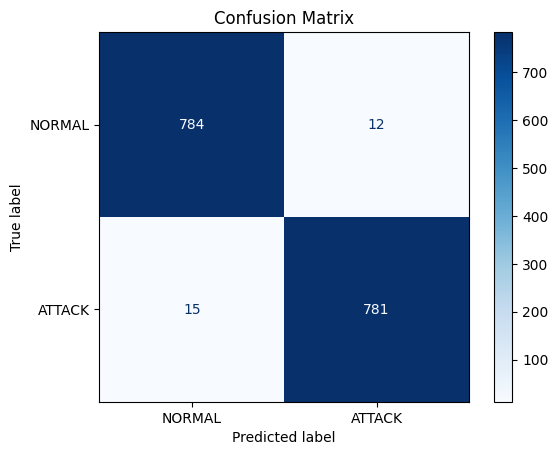

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_test_pred,

    display_labels=[

        "NORMAL",

        "ATTACK"

    ],

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.show()